# Notebook 2: Implementacja modeli

## Wykrywanie cyberprzemocy w polskich tweetach

W tym notebooku implementujemy i porównujemy dwa podejścia do klasyfikacji tekstu (wykrywanie hejtu):
1. **Podejście klasyczne:** TF-IDF + klasyfikatory (SVM / Naive Bayes / Logistic Regression)
2. **Podejście Transformer:** Fine-tuning polskiego modelu językowego (np. HerBERT)

Dane (zbiory `train.csv`, `val.csv`, `test.csv`) pochodzą z procesu przetwarzania wykonanego w Notebooku 1.

### 1. Instalacja bibliotek i import



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

# Ekstrakcja cech dla podejścia klasycznego
from sklearn.feature_extraction.text import TfidfVectorizer

# Klasyczne modele uczenia maszynowego
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Metryki ewaluacji
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# Konfiguracja ostrzeżeń i wyglądu wykresów
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

print("Biblioteki gotowe do akcji!")

Biblioteki gotowe do akcji!


### 2. Wczytanie danych

Wczytujemy przygotowane w poprzednim etapie zbiory danych (treningowy, walidacyjny i testowy) oraz definiujemy stałe dla nazw kolumn, z których będziemy korzystać w modelach.

In [3]:
# Wczytanie danych z Notebook 1
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

print(f"Rozmiary zbiorów -> Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Zabezpieczenie przed pustymi wartościami - zamieniamy je na puste stringi
train_df = train_df.fillna("")
val_df = val_df.fillna("")
test_df = test_df.fillna("")

# Zdefiniowanie stałych dla nazw kolumn
TEXT_COL = "sentence"       # oryginalny tekst (dla modelu Transformer)
CLEAN_COL = "cleaned_text"  # przetworzony tekst (dla modeli klasycznych)
LABEL_COL = "label"         # etykieta (0=brak hejtu, 1=hejt)

print(f"\nUżywane kolumny:")
print(f" - Tekst oryginalny: '{TEXT_COL}'")
print(f" - Tekst przetworzony: '{CLEAN_COL}'")
print(f" - Etykieta: '{LABEL_COL}'")

Rozmiary zbiorów -> Train: 3500, Val: 750, Test: 750

Używane kolumny:
 - Tekst oryginalny: 'sentence'
 - Tekst przetworzony: 'cleaned_text'
 - Etykieta: 'label'


## CZĘŚĆ A: Podejście klasyczne (TF-IDF + klasyfikatory)

Implementujemy pipeline klasyczny. Zaczynamy od przygotowania zmiennych $X$ (tekst) i $y$ (etykiety), a następnie wektoryzujemy wyczyszczony tekst za pomocą metody TF-IDF.

In [4]:
# Przygotowanie danych dla podejścia klasycznego
# Do X bierzemy nasz wyczyszczony tekst (bez stopwords, tagów, lematyzowany)
X_train_clean = train_df[CLEAN_COL].fillna("").values
X_val_clean = val_df[CLEAN_COL].fillna("").values
X_test_clean = test_df[CLEAN_COL].fillna("").values

# Do y bierzemy etykiety (0 lub 1)
y_train = train_df[LABEL_COL].values
y_val = val_df[LABEL_COL].values
y_test = test_df[LABEL_COL].values

print("Zmienne X i y przygotowane!")

Zmienne X i y przygotowane!


In [5]:
# Wektoryzacja TF-IDF
# Używamy unigramów i bigramów
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

# Dopasowujemy wektoryzator TYLKO na zbiorze treningowym (fit_transform)
# a na walidacyjnym i testowym robimy tylko transformację (transform)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print(f"Wymiary macierzy TF-IDF (train): {X_train_tfidf.shape}")
print(f"Liczba cech (unikalne n-gramy, które model bierze pod uwagę): {X_train_tfidf.shape[1]}")

Wymiary macierzy TF-IDF (train): (3500, 3742)
Liczba cech (unikalne n-gramy, które model bierze pod uwagę): 3742


In [6]:
# Słownik z naszymi klasyfikatorami
classifiers = {
    "SVM (LinearSVC)": LinearSVC(max_iter=5000, random_state=42),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
}

classic_results = {}
target_names_list = ["Brak hejtu", "Hejt"]

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Trening: {name}")
    print(f"{'='*50}")

    # Trening modelu
    clf.fit(X_train_tfidf, y_train)

    # predykcja na zbiorze WALIDACYJNYM
    y_val_pred = clf.predict(X_val_tfidf)

    # Obliczanie metryk
    acc = accuracy_score(y_val, y_val_pred)
    # Używamy weighted avg, mamy niezbalansowane klasy
    f1 = f1_score(y_val, y_val_pred, average="weighted")

    classic_results[name] = {
        "model": clf,
        "val_accuracy": acc,
        "val_f1": f1,
        "val_predictions": y_val_pred,
    }

    print(f"Accuracy (val): {acc:.4f}")
    print(f"F1-score (val): {f1:.4f}")
    print(f"\nRaport klasyfikacji (val):")
    print(classification_report(y_val, y_val_pred, target_names=target_names_list))


Trening: SVM (LinearSVC)
Accuracy (val): 0.9267
F1-score (val): 0.9096

Raport klasyfikacji (val):
              precision    recall  f1-score   support

  Brak hejtu       0.93      0.99      0.96       688
        Hejt       0.67      0.23      0.34        62

    accuracy                           0.93       750
   macro avg       0.80      0.61      0.65       750
weighted avg       0.91      0.93      0.91       750


Trening: Naive Bayes
Accuracy (val): 0.9267
F1-score (val): 0.9055

Raport klasyfikacji (val):
              precision    recall  f1-score   support

  Brak hejtu       0.93      0.99      0.96       688
        Hejt       0.73      0.18      0.29        62

    accuracy                           0.93       750
   macro avg       0.83      0.59      0.62       750
weighted avg       0.91      0.93      0.91       750


Trening: Logistic Regression
Accuracy (val): 0.8747
F1-score (val): 0.8843

Raport klasyfikacji (val):
              precision    recall  f1-score   

In [7]:
# Wybór na podstawie F1-score w zb wal.
best_classic_name = max(classic_results, key=lambda x: classic_results[x]["val_f1"])
best_classic = classic_results[best_classic_name]

print(f"Najlepszy klasyfikator klasyczny: {best_classic_name}")
print(f"F1-score (val): {best_classic['val_f1']:.4f}")

# Ewaluacja zwycięzcy na OSTATECZNYM zb test
y_test_pred_classic = best_classic["model"].predict(X_test_tfidf)
classic_test_acc = accuracy_score(y_test, y_test_pred_classic)
classic_test_f1 = f1_score(y_test, y_test_pred_classic, average="weighted")

print(f"\nWyniki na zbiorze testowym ({best_classic_name}):")
print(f"Accuracy: {classic_test_acc:.4f}")
print(f"F1-score: {classic_test_f1:.4f}")
print(f"\nRaport klasyfikacji (test):")
print(classification_report(y_test, y_test_pred_classic, target_names=["Brak hejtu", "Hejt"]))

Najlepszy klasyfikator klasyczny: SVM (LinearSVC)
F1-score (val): 0.9096

Wyniki na zbiorze testowym (SVM (LinearSVC)):
Accuracy: 0.9227
F1-score: 0.8995

Raport klasyfikacji (test):
              precision    recall  f1-score   support

  Brak hejtu       0.93      0.99      0.96       688
        Hejt       0.64      0.15      0.24        62

    accuracy                           0.92       750
   macro avg       0.79      0.57      0.60       750
weighted avg       0.90      0.92      0.90       750



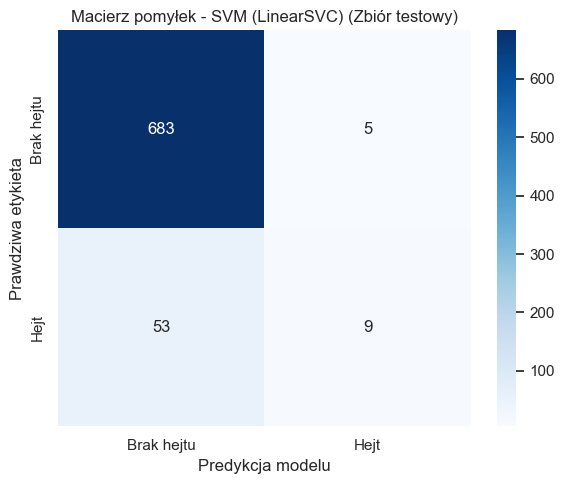

In [8]:
# Generowanie macierzy pomyłek dla najlepszego klasycznego modelu
cm_classic = confusion_matrix(y_test, y_test_pred_classic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_classic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Brak hejtu", "Hejt"],
    yticklabels=["Brak hejtu", "Hejt"],
)

plt.title(f"Macierz pomyłek - {best_classic_name} (Zbiór testowy)")
plt.xlabel("Predykcja modelu")
plt.ylabel("Prawdziwa etykieta")
plt.tight_layout()
plt.show()

## CZĘŚĆ B: Podejście oparte na Transformerach (HerBERT)

Fine-tuning modelu **HerBERT** (polskiej wersji BERT).
W przeciwieństwie do podejścia klasycznego, Transformery świetnie radzą sobie z analizą kontekstu całego zdania. Wprowadzamy do nich **surowy tekst**, ponieważ usunięcie z niego znaków interpunkcyjnych i "stop words" pozbawiłoby model cennych informacji o budowie zdania.

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

# Sprawdzenie dostępności GPU (KRYTYCZNE DLA TRANSFORMERÓW)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Urządzenie do obliczeń: {device}")
if device.type == "cuda":
    print(f"Nazwa GPU: {torch.cuda.get_device_name(0)}")
else:
    print("UWAGA: Używasz CPU! Trening modelu może potrwać bardzo długo.")

# Załadowanie tokenizatora i modelu HerBERT
MODEL_NAME = "allegro/herbert-base-cased"

print(f"\nPobieranie/ładowanie modelu: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# num_labels=2, ponieważ mamy klasyfikację binarną (0 - brak hejtu, 1 - hejt)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

print("Model załadowany pomyślnie!")
print(f"Liczba parametrów modelu: {sum(p.numel() for p in model.parameters()):,}")

Urządzenie do obliczeń: cpu
UWAGA: Używasz CPU! Trening modelu może potrwać bardzo długo.

Pobieranie/ładowanie modelu: allegro/herbert-base-cased...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 27744.53it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.sso.sso_relationship.bias              | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.sso.sso_relationship.weight            | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/arc

Model załadowany pomyślnie!
Liczba parametrów modelu: 124,444,418


In [10]:
class CyberbullyingDataset(Dataset):


    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenizacja tekstu specjalnie pod model HerBERT
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label, dtype=torch.long),
        }

# Przygotowanie DataLoaderów
MAX_LENGTH = 128
BATCH_SIZE = 16

train_dataset = CyberbullyingDataset(
    train_df[TEXT_COL].values, train_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)
val_dataset = CyberbullyingDataset(
    val_df[TEXT_COL].values, val_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)
test_dataset = CyberbullyingDataset(
    test_df[TEXT_COL].values, test_df[LABEL_COL].values, tokenizer, MAX_LENGTH
)

# DataLoader dzieli nasze dane na paczki (batche) o rozmiarze 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Batche treningowe: {len(train_loader)}")
print(f"Batche walidacyjne: {len(val_loader)}")

Batche treningowe: 219
Batche walidacyjne: 47


In [11]:
# Hiperparametry treningu
EPOCHS = 3
LEARNING_RATE = 2e-5

# Optimizer AdamW to standard dla Transforms
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)
print("Optymalizator i scheduler gotowe!")

Optymalizator i scheduler gotowe!


In [12]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, acc, f1, np.array(all_preds), np.array(all_labels)

print("Funkcje trenujące i walidacyjne załadowane!")

Funkcje trenujące i walidacyjne załadowane!


In [13]:
import time

# Pętla treningowa
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Rozpoczynam trening HerBERT ({EPOCHS} epok)... \n")

for epoch in range(EPOCHS):
    start_time = time.time()
    print(f"--- Trening Epoki {epoch+1}/{EPOCHS} w toku (to może trochę potrwać) ---")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    elapsed = time.time() - start_time
    print(f"✅ Zakończono! Czas epoki: {elapsed/60:.2f} min")
    print(f" Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f" Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}\n")

Rozpoczynam trening HerBERT (3 epok)... 

--- Trening Epoki 1/3 w toku (to może trochę potrwać) ---
✅ Zakończono! Czas epoki: 13.62 min
 Train Loss: 0.2925 | Train Acc: 0.9137
 Val Loss: 0.1821 | Val Acc: 0.9293 | Val F1: 0.9129

--- Trening Epoki 2/3 w toku (to może trochę potrwać) ---
✅ Zakończono! Czas epoki: 13.37 min
 Train Loss: 0.2061 | Train Acc: 0.9277
 Val Loss: 0.1782 | Val Acc: 0.9360 | Val F1: 0.9281

--- Trening Epoki 3/3 w toku (to może trochę potrwać) ---
✅ Zakończono! Czas epoki: 13.14 min
 Train Loss: 0.1321 | Train Acc: 0.9580
 Val Loss: 0.1950 | Val Acc: 0.9387 | Val F1: 0.9351



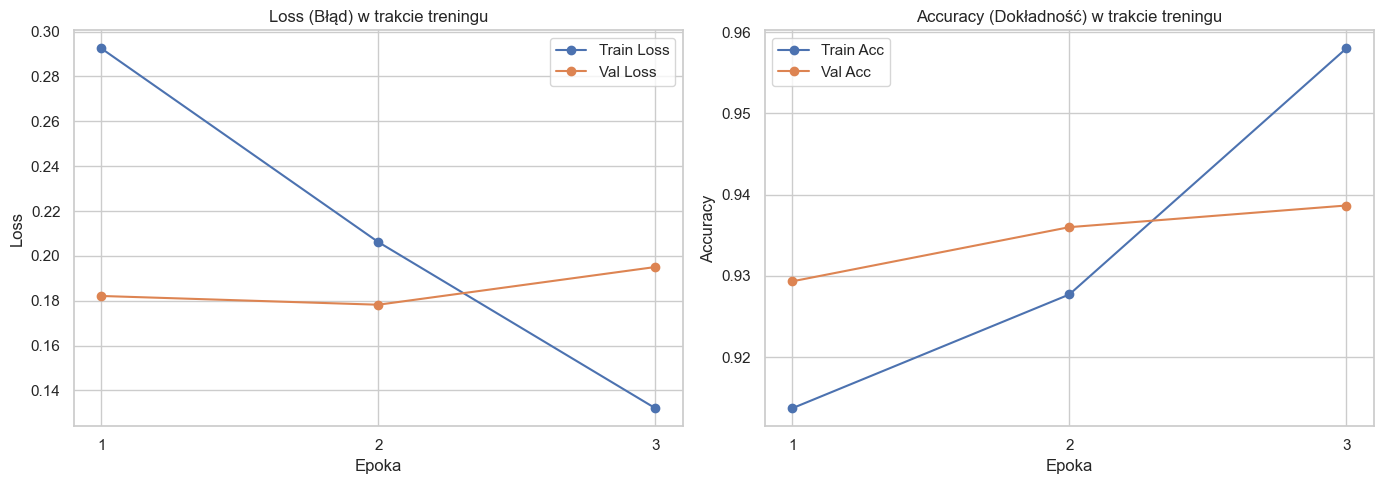

In [14]:
# Wykresy treningu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_title("Loss (Błąd) w trakcie treningu")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss")
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(["1", "2", "3"])
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(history["val_acc"], label="Val Acc", marker="o")
axes[1].set_title("Accuracy (Dokładność) w trakcie treningu")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(["1", "2", "3"])
axes[1].legend()

plt.tight_layout()
plt.show()

Ewaluacja modelu HerBERT na ostatecznym zbiorze testowym...

Wyniki HerBERT na zbiorze testowym:
Accuracy: 0.9333
F1-score: 0.9251

Raport klasyfikacji:
              precision    recall  f1-score   support

  Brak hejtu       0.95      0.98      0.96       688
        Hejt       0.67      0.39      0.49        62

    accuracy                           0.93       750
   macro avg       0.81      0.68      0.73       750
weighted avg       0.92      0.93      0.93       750



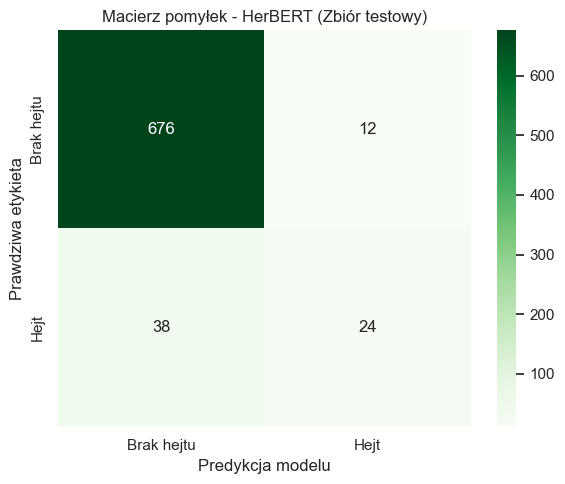

In [15]:
print("Ewaluacja modelu HerBERT na ostatecznym zbiorze testowym...")
test_loss, test_acc, test_f1, y_test_pred_transformer, y_test_true = evaluate(
    model, test_loader, device
)

print(f"\nWyniki HerBERT na zbiorze testowym:")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"\nRaport klasyfikacji:")
print(classification_report(y_test_true, y_test_pred_transformer, target_names=["Brak hejtu", "Hejt"]))

# Macierz pomyłek - Transformer
cm_transformer = confusion_matrix(y_test_true, y_test_pred_transformer)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_transformer,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Brak hejtu", "Hejt"],
    yticklabels=["Brak hejtu", "Hejt"],
)

plt.title("Macierz pomyłek - HerBERT (Zbiór testowy)")
plt.xlabel("Predykcja modelu")
plt.ylabel("Prawdziwa etykieta")
plt.tight_layout()
plt.show()

In [17]:
# Zapis do pliku
results_df = test_df.copy()
results_df["pred_classic"] = y_test_pred_classic  # Zmienna z Komórki 10
results_df["pred_transformer"] = y_test_pred_transformer
results_df.to_csv("test_predictions.csv", index=False)

# Zapis podsumowania
summary = {
    "classic_name": best_classic_name,
    "classic_accuracy": classic_test_acc,
    "classic_f1": classic_test_f1,
    "transformer_name": "HerBERT",
    "transformer_accuracy": test_acc,
    "transformer_f1": test_f1,
}

with open("results_summary.pkl", "wb") as f:
    pickle.dump(summary, f)

print("Predykcje zapisane do: test_predictions.csv")
print("Podsumowanie wyników zapisane do: results_summary.pkl")


Predykcje zapisane do: test_predictions.csv
Podsumowanie wyników zapisane do: results_summary.pkl


### Podsumowanie

W tym notebooku wykonaliśmy serię eksperymentów, aby wyłonić najlepszy model do detekcji cyberprzemocy:

* **Zaimplementowaliśmy podejście klasyczne:** Wykorzystaliśmy wektoryzację TF-IDF oraz przetestowaliśmy algorytmy: SVM, Naive Bayes i Regresję Logistyczną. Najlepszy okazał się **SVM**, osiągając wysoką ogólną dokładność, ale poległ na klasie mniejszościowej (wykrył zaledwie 9 z 62 przypadków hejtu).
* **Zaimplementowaliśmy nowoczesny model językowy (Transformer):** Przeprowadziliśmy pomyślny fine-tuning polskiego modelu **HerBERT**. Dzięki mechanizmowi atencji i analizie pełnego kontekstu zdania, model ten wyłapał niemal 3-krotnie więcej hejterskich wpisów (24 wykryte przypadki) niż najlepszy model klasyczny.
* **Zapisaliśmy wyniki:** Predykcje obu modeli oraz podsumowanie głównych metryk zostały wyeksportowane do plików (`test_predictions.csv` oraz `results_summary.pkl`) w celu dalszej ewaluacji.

Szczegółowe porównanie wyników oraz jakościowa analiza błędów (sprawdzenie, na jakich konkretnie tweetach pomyliły się nasze modele) znajdują się w Notebooku 3.